# Belka wspornikowa obciążona równomiernie: normalizacja zamiast wag

Belka Eulera–Bernoulliego o przekroju prostokątnym $b\times 2c$. Koniec swobodny w $x=0$, utwierdzenie w $x=l$. Górną powierzchnię obciąża równomiernie ciśnienie $q$ działające w dół. W modelu belkowym działa ono jako obciążenie liniowe $p=q\,b$ (tu $q=0{,}02$ kN/cm² $=200$ kPa). Ciężar własny pomijamy.

<p align="center"><img src="../../figures/cantilever_geometry.png" width="600"></p>

<div align="center">

**Dane:**

| $p$ | $b$ | $E$ | $c$ | $l$ |
|---|---|---|---|---|
| 0,4 kN/cm | 20 cm | 30 GPa = 3000 kN/cm² | 25 cm | 200 cm |

</div>

### 1. Związek konstytutywny

$$M_z=-EJ_z\,\dfrac{d^2\mathsf v}{dx^2},\qquad J_z=\frac{(2c)^3\,b}{12}=\frac23\,b\,c^3$$

### 2. Równanie równowagi $\rightarrow$ równanie równowagi w przemieszczeniach

Z równowagi elementu belki $dx$:

$$\frac{dT_y}{dx}=p,\qquad \frac{dM_z}{dx}=T_y\qquad\Rightarrow\qquad \frac{d^2M_z}{dx^2}=p,\qquad x\in[0,\,l]$$

Po podstawieniu związku konstytutywnego:

$$EJ_z\,\dfrac{d^4\mathsf v}{dx^4}+p=0$$

### 3. Warunki brzegowe

| koniec swobodny $x=0$ | utwierdzenie $x=l$ |
|---|---|
| $M_z(0)=0\;\Leftrightarrow\;\left.\dfrac{d^2\mathsf v}{dx^2}\right\vert_{x=0}=0$ | $\mathsf v(l)=0$ |
| $T_y(0)=0\;\Leftrightarrow\;\left.\dfrac{d^3\mathsf v}{dx^3}\right\vert_{x=0}=0$ | $\varphi(l)=\left.\dfrac{d\mathsf v}{dx}\right\vert_{x=l}=0$ |

**Rozwiązanie analityczne**

$$\begin{aligned}
EJ_z\,\dfrac{d^3\mathsf v}{dx^3} &= -p\,x + C_1 & T_y(0)=0 &\;\Rightarrow\; C_1=0\\
EJ_z\,\dfrac{d^2\mathsf v}{dx^2} &= -\tfrac12 p\,x^2 + C_2 & M_z(0)=0 &\;\Rightarrow\; C_2=0\\
EJ_z\,\dfrac{d\mathsf v}{dx} &= -\tfrac16 p\,x^3 + C_3 & \left.\dfrac{d\mathsf v}{dx}\right\vert_{x=l}=0 &\;\Rightarrow\; C_3=\tfrac16 p\,l^3\\
EJ_z\,\mathsf v(x) &= -\tfrac1{24} p\,x^4 + \tfrac16 p\,l^3 x + C_4 & \mathsf v(l)=0 &\;\Rightarrow\; C_4=-\tfrac18 p\,l^4
\end{aligned}$$

$$\mathsf v(x)=\frac{p}{16\,E\,b\,c^3}\left(4l^3x-x^4-3l^4\right),\qquad M_z(x)=\tfrac12\,p\,x^2,\qquad T_y(x)=p\,x$$

**Problem.** Koszt PINN to suma reszty równania i czterech warunków brzegowych. W zmiennych wymiarowych składniki te różnią się o wiele rzędów wielkości. Pierwszy odruch to dobranie wag $w_i$ w $L=\sum_iw_i L_i$. Tutaj pokazujemy drugą drogę: **normalizację zadania**.

To samo zadanie rozwiążemy w trzech sformułowaniach. Każde ma własną zmienną niezależną i pochodne liczone po niej:

| sformułowanie | zmienna | niewiadoma sieci | równanie | dziedzina |
|---|---|---|---|---|
| 1. wymiarowe | $x$ [cm] | $\mathsf v$ [cm] | $\dfrac{d^4\mathsf v}{dx^4}+\dfrac{p}{EJ_z}=0$ | $[0,\,l]$ |
| 2. bezwymiarowe | $\xi=x/l$ | $\mathsf v$ [cm] | $\dfrac{d^4\mathsf v}{d\xi^4}+\gamma_{\mathrm{ref}}=0$ | $[0,\,1]$ |
| 3. skalowane | $\xi=x/l$ | $\hat v=\mathsf v/\gamma_{\mathrm{ref}}$ | $\dfrac{d^4\hat v}{d\xi^4}+1=0$ | $[0,\,1]$ |

Plan: (1a) wymiarowe z wagami 1, (1b) wymiarowe z dobranymi wagami, (2) bezwymiarowe z wagami 1, (3) skalowane z wagami 1.

In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"   # DeepXDE liczy w PyTorch

import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
import torch
# dde.config.set_default_float("float64")   # obliczenia w podwójnej precyzji (domyślnie float32)
SEED = 0
dde.config.set_random_seed(SEED)

# dane [kN, cm]
p = 0.4      # obciążenie liniowe [kN/cm]
b = 20.0     # szerokość przekroju [cm]
E = 3000.0   # moduł Younga [kN/cm²]
c = 25.0     # połowa wysokości przekroju [cm]
l = 200.0    # długość wspornika [cm]
J = 2 / 3 * b * c**3             # moment bezwładności [cm⁴]
gamma = p * l**4 / (E * J)       # skala ugięcia γ_ref [cm]
print("γ_ref =", gamma, "cm")

# parametry sieci i treningu
ITERATIONS = 2000   # liczba iteracji
LR = 0.001          # krok uczenia (Adam)
WIDTH = 50          # neurony w warstwie ukrytej (3 warstwy)
N_COL = 15          # punkty kolokacyjne


LOSS_LABELS = ["PDE", "M(0)=0", "T(0)=0", "φ(l)=0", "v(l)=0"]

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64
γ_ref = 1.024 cm


In [2]:
# rozwiązanie dokładne (tylko do testowania)
def v_exact(x):
    return p / (16 * E * b * c**3) * (4 * l**3 * x - x**4 - 3 * l**4)

def M_exact(x):
    return p * x**2 / 2

def T_exact(x):
    return p * x

# punkty do wykresów (kolumna 500 × 1, tak jak oczekuje sieć)
x = np.linspace(0, l, 500).reshape(500, 1)
xi = x / l

# błąd względny L2 ugięcia
def error_L2(v):
    return np.linalg.norm(v - v_exact(x)) / np.linalg.norm(v_exact(x))

# warunki brzegowe działają w punktach:
def free_end(x, on_boundary):      # lewy koniec: x = 0
    return on_boundary and np.isclose(x[0], 0)

# to samo jako wyrażenie lambda: funkcja bez nazwy zapisana w jednej linijce,
# "lambda argumenty: wynik"; można ją od razu przekazać do DirichletBC/OperatorBC
# free_end = lambda x, on_boundary: on_boundary and np.isclose(x[0], 0)

def clamped_end(x, on_boundary):   # prawy koniec: x = l albo ξ = 1
    return on_boundary and x[0] > 0

In [3]:
def plot(v, M, T, losshistory, title):
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title + ",   błąd względny L2 ugięcia = %.1e" % error_L2(v))

    ax[0, 0].plot(x, v_exact(x), "k-", label="dokładne")
    ax[0, 0].plot(x, v, "r--", label="PINN")
    ax[0, 0].set(xlabel="x [cm]", ylabel="v(x) [cm]")
    ax[0, 0].legend()

    ax[0, 1].plot(x, M_exact(x), "k-")
    ax[0, 1].plot(x, M, "r--")
    ax[0, 1].set(xlabel="x [cm]", ylabel="$M_z(x)$ [kNcm]")

    ax[1, 0].plot(x, T_exact(x), "k-")
    ax[1, 0].plot(x, T, "r--")
    ax[1, 0].set(xlabel="x [cm]", ylabel="$T_y(x)$ [kN]")

    ax[1, 1].semilogy(losshistory.steps, losshistory.loss_train, label=LOSS_LABELS)
    ax[1, 1].set(xlabel="iteracja", title="składniki kosztu")
    ax[1, 1].legend(fontsize=8)
    fig.tight_layout()

## 1. Sformułowanie wymiarowe (zmienna $x$)

$$\dfrac{d^4\mathsf v}{dx^4}+\frac{p}{EJ_z}=0,\qquad \mathsf v(x)=\frac{p}{16\,E\,b\,c^3}\left(4l^3x-x^4-3l^4\right)$$

$$M_z(x)=-EJ_z\,\dfrac{d^2\mathsf v}{dx^2},\qquad T_y(x)=-EJ_z\,\dfrac{d^3\mathsf v}{dx^3}$$

In [4]:
# dziedzina: x ∈ [0, l]
geom_x = dde.geometry.Interval(0, l)

# pochodne ugięcia po x (każda to pochodna poprzedniej)
def dv_dx(v, x):
    return dde.grad.jacobian(v, x)

def d2v_dx2(v, x):
    return dde.grad.jacobian(dv_dx(v, x), x)

def d3v_dx3(v, x):
    return dde.grad.jacobian(d2v_dx2(v, x), x)

def d4v_dx4(v, x):
    return dde.grad.jacobian(d3v_dx3(v, x), x)

# reszta z równania równowagi w przemieszczeniach (podzielonego przez EJ)
def pde_x(x, v):
    return d4v_dx4(v, x) + p / (E * J)

# warunki brzegowe: M_z i T_y na końcu swobodnym, φ i v w utwierdzeniu
def bc_M(x, v, _):     # M_z(0) = 0
    return d2v_dx2(v, x)

def bc_T(x, v, _):     # T_y(0) = 0
    return d3v_dx3(v, x)

def bc_phi(x, v, _):   # φ(l) = 0
    return dv_dx(v, x)

def bc_v(x):           # v(l) = 0: zadana wartość ugięcia
    return 0

bcs_x = [
    dde.icbc.OperatorBC(geom_x, bc_M, free_end),
    dde.icbc.OperatorBC(geom_x, bc_T, free_end),
    dde.icbc.OperatorBC(geom_x, bc_phi, clamped_end),
    dde.icbc.DirichletBC(geom_x, bc_v, clamped_end),
]

### 1a. Wagi jednostkowe

Compiling model...
'compile' took 0.883474 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.28e-12, 0.00e+00, 1.58e-02, 7.89e-08, 9.01e-02]    [1.28e-12, 0.00e+00, 1.58e-02, 7.89e-08, 9.01e-02]    []  


200       [3.62e-12, 5.81e-14, 3.76e-12, 7.58e-09, 7.76e-12]    [3.62e-12, 5.81e-14, 3.76e-12, 7.58e-09, 7.76e-12]    []  
400       [3.60e-12, 6.65e-20, 1.11e-17, 7.56e-09, 5.93e-18]    [3.60e-12, 6.65e-20, 1.11e-17, 7.56e-09, 5.93e-18]    []  
600       [3.60e-12, 6.75e-20, 1.16e-17, 7.52e-09, 6.73e-18]    [3.60e-12, 6.75e-20, 1.16e-17, 7.52e-09, 6.73e-18]    []  
800       [3.60e-12, 6.91e-20, 1.16e-17, 7.48e-09, 6.63e-18]    [3.60e-12, 6.91e-20, 1.16e-17, 7.48e-09, 6.63e-18]    []  
1000      [3.60e-12, 7.11e-20, 1.17e-17, 7.43e-09, 6.51e-18]    [3.60e-12, 7.11e-20, 1.17e-17, 7.43e-09, 6.51e-18]    []  
1200      [3.60e-12, 7.35e-20, 1.18e-17, 7.37e-09, 6.38e-18]    [3.60e-12, 7.35e-20, 1.18e-17, 7.37e-09, 6.38e-18]    []  
1400      [3.60e-12, 7.63e-20, 1.19e-17, 7.30e-09, 6.23e-18]    [3.60e-12, 7.63e-20, 1.19e-17, 7.30e-09, 6.23e-18]    []  
1600      [3.60e-12, 7.95e-20, 1.20e-17, 7.22e-09, 6.07e-18]    [3.60e-12, 7.95e-20, 1.20e-17, 7.22e-09, 6.07e-18]    []  
1800      [3.60e

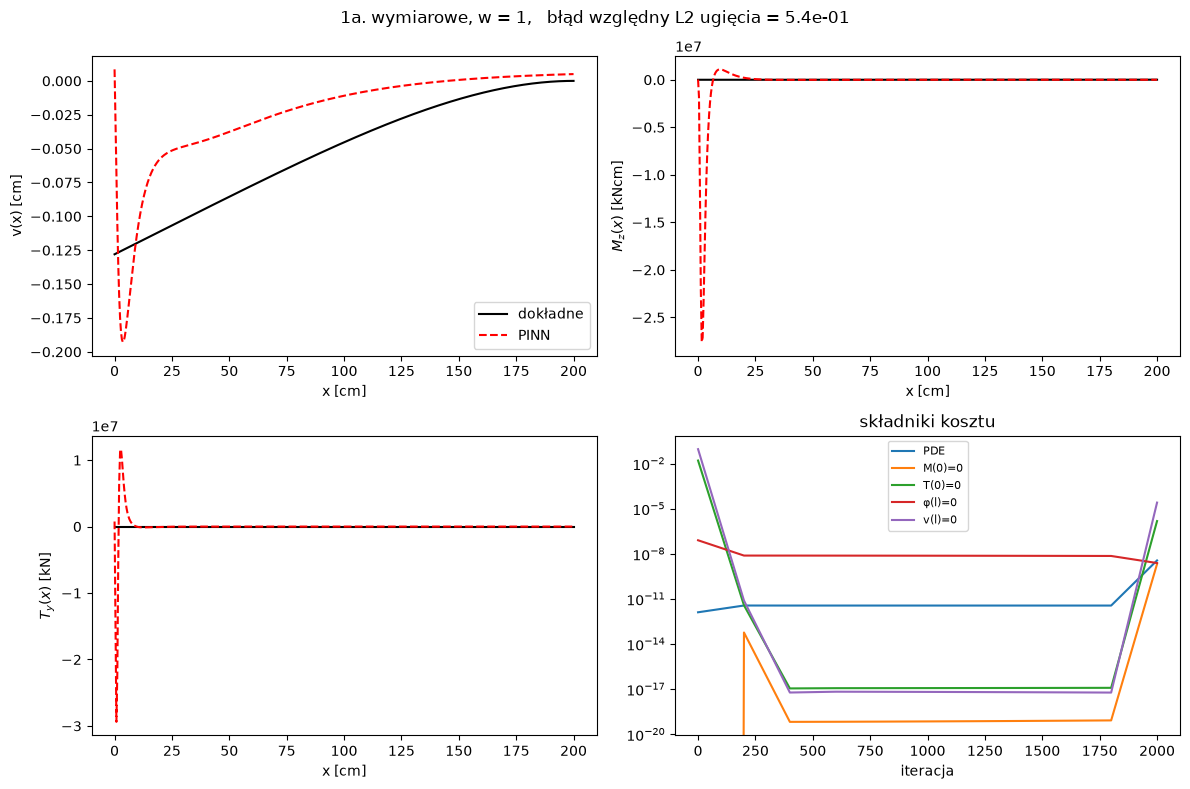

In [5]:
# ziarno losowania: ten sam start sieci w każdym wariancie
dde.config.set_random_seed(SEED)

# składamy nasze dane do modelu DeepXDE
data = dde.data.PDE(geom_x, pde_x, bcs_x, num_domain=N_COL, num_boundary=2)

# definiujemy sieć neuronową: wejście x, 3 warstwy ukryte po WIDTH neuronów, wyjście v
net = dde.nn.FNN([1, WIDTH, WIDTH, WIDTH, 1], "tanh", "Glorot uniform")

# inicjalizujemy model DeepXDE oraz kompilujemy go z wybranym optymalizatorem
model = dde.Model(data, net)
model.compile("adam", lr=LR)

# trenujemy model i zapisujemy historię kosztu oraz stan uczenia
losshistory1a, train_state1a = model.train(iterations=ITERATIONS, display_every=200)

# ugięcie i siły przekrojowe z sieci
v1a = model.predict(x)
M1a = model.predict(x, operator=lambda x, v: -E * J * d2v_dx2(v, x))   # M_z = -EJ d²v/dx²
T1a = model.predict(x, operator=lambda x, v: -E * J * d3v_dx3(v, x))   # T_y = -EJ d³v/dx³
plot(v1a, M1a, T1a, losshistory1a, "1a. wymiarowe, w = 1")

### 1b. Dobrane wagi

Klasyczny ratunek: każdą wagę dobieramy tak, żeby jej składnik startował z wartości 1, czyli $w_i = 1/L_i^{(0)}$. Start sieci jest ten sam (to samo ziarno), więc $L_i^{(0)}$ bierzemy z wariantu 1a. Składnik równy zero na starcie dostaje wagę 1.

['PDE', 'M(0)=0', 'T(0)=0', 'φ(l)=0', 'v(l)=0']
[1.28466275e-12 0.00000000e+00 1.58004134e-02 7.88730231e-08
 9.00533017e-02]
wagi: [np.float64(778414413052.1172), 1, np.float64(63.28948320620251), np.float64(12678606.209051562), np.float64(11.104534545955861)]
Compiling model...
'compile' took 0.000069 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00]    [1.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00]    []  
200       [1.77e+01, 1.33e-09, 1.97e-01, 9.25e-01, 8.56e-02]    [1.77e+01, 1.33e-09, 1.97e-01, 9.25e-01, 8.56e-02]    []  
400       [1.01e+00, 1.08e-09, 2.01e-01, 9.54e-01, 1.35e-02]    [1.01e+00, 1.08e-09, 2.01e-01, 9.54e-01, 1.35e-02]    []  
600       [5.75e-01, 1.03e-09, 2.01e-01, 9.30e-01, 4.25e-04]    [5.75e-01, 1.03e-09, 2.01e-01, 9.30e-01, 4.25e-04]    []  
800       [5.66e-01, 1.02e-09, 2.01e-01, 8.91e-01, 

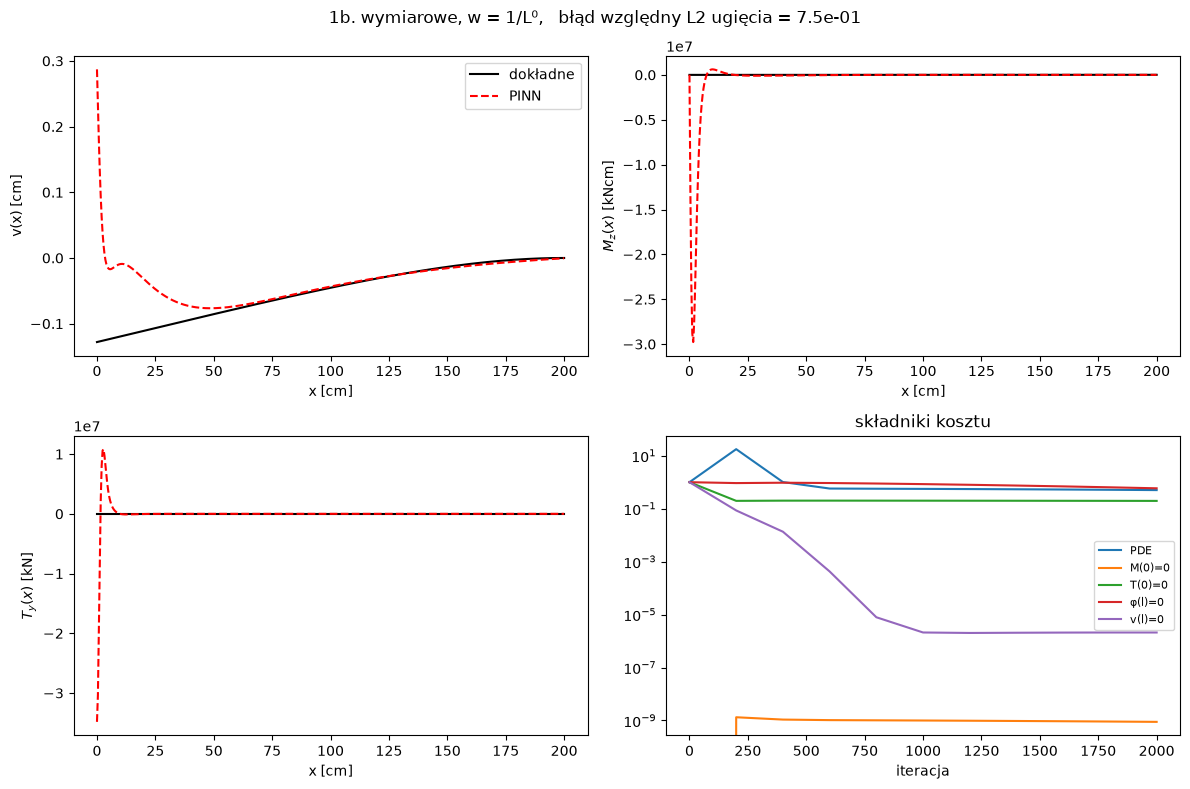

In [6]:
# te same kroki co w 1a, zebrane w jedną funkcję (użyjemy jej też w sformułowaniach 2 i 3)
def train(geom, pde, bcs, loss_weights=None):
    dde.config.set_random_seed(SEED)
    data = dde.data.PDE(geom, pde, bcs, num_domain=N_COL, num_boundary=2)
    net = dde.nn.FNN([1, WIDTH, WIDTH, WIDTH, 1], "tanh", "Glorot uniform")
    model = dde.Model(data, net)
    model.compile("adam", lr=LR, loss_weights=loss_weights)
    losshistory, state = model.train(iterations=ITERATIONS, display_every=200)
    return model, losshistory

L0 = losshistory1a.loss_train[0]   # składniki kosztu w iteracji 0 (wariant 1a)
print(LOSS_LABELS)
print(L0)

# M(0)=0 startuje z zera, więc dostaje wagę 1
weights = [1 / L0[0], 1, 1 / L0[2], 1 / L0[3], 1 / L0[4]]
print("wagi:", weights)

model, losshistory1b = train(geom_x, pde_x, bcs_x, loss_weights=weights)

v1b = model.predict(x)
M1b = model.predict(x, operator=lambda x, v: -E * J * d2v_dx2(v, x))   # M_z = -EJ d²v/dx²
T1b = model.predict(x, operator=lambda x, v: -E * J * d3v_dx3(v, x))   # T_y = -EJ d³v/dx³
plot(v1b, M1b, T1b, losshistory1b, "1b. wymiarowe, w = 1/L⁰")

## 2. Sformułowanie bezwymiarowe (zmienna $\xi=x/l$), wagi jednostkowe

Podstawiamy $x=l\,\xi$, więc $\dfrac{d}{dx}=\dfrac1l\dfrac{d}{d\xi}$ i $\;\dfrac{d^4\mathsf v}{dx^4}=\dfrac1{l^4}\dfrac{d^4\mathsf v}{d\xi^4}$. Sieć nadal przybliża ugięcie w centymetrach, ale na przedziale $\xi\in[0,\,1]$:

$$\dfrac{d^4\mathsf v}{d\xi^4}+\gamma_{\mathrm{ref}}=0,\qquad \mathsf v(\xi)=\frac{\gamma_{\mathrm{ref}}}{24}\left(4\xi-\xi^4-3\right),\qquad \gamma_{\mathrm{ref}}=\frac{p\,l^4}{EJ_z}$$

$$M_z(\xi)=-\frac{EJ_z}{l^2}\,\dfrac{d^2\mathsf v}{d\xi^2},\qquad T_y(\xi)=-\frac{EJ_z}{l^3}\,\dfrac{d^3\mathsf v}{d\xi^3}$$

Compiling model...
'compile' took 0.000092 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [9.18e-01, 0.00e+00, 1.58e-02, 5.36e-02, 7.41e-02]    [9.18e-01, 0.00e+00, 1.58e-02, 5.36e-02, 7.41e-02]    []  
200       [1.65e-02, 1.42e-02, 4.31e-04, 1.62e-03, 3.00e-04]    [1.65e-02, 1.42e-02, 4.31e-04, 1.62e-03, 3.00e-04]    []  
400       [2.25e-04, 4.65e-07, 7.20e-07, 1.17e-07, 3.03e-09]    [2.25e-04, 4.65e-07, 7.20e-07, 1.17e-07, 3.03e-09]    []  
600       [1.65e-04, 7.46e-07, 2.67e-08, 7.30e-08, 1.85e-09]    [1.65e-04, 7.46e-07, 2.67e-08, 7.30e-08, 1.85e-09]    []  
800       [1.36e-04, 4.71e-07, 2.60e-08, 2.11e-08, 1.34e-09]    [1.36e-04, 4.71e-07, 2.60e-08, 2.11e-08, 1.34e-09]    []  
1000      [1.18e-04, 2.79e-07, 9.45e-08, 2.91e-09, 5.85e-12]    [1.18e-04, 2.79e-07, 9.45e-08, 2.91e-09, 5.85e-12]    []  
1200      [1.00e-04, 2.56e-07, 5.75e-09, 9.15e-09, 1.26e-09]    [1.

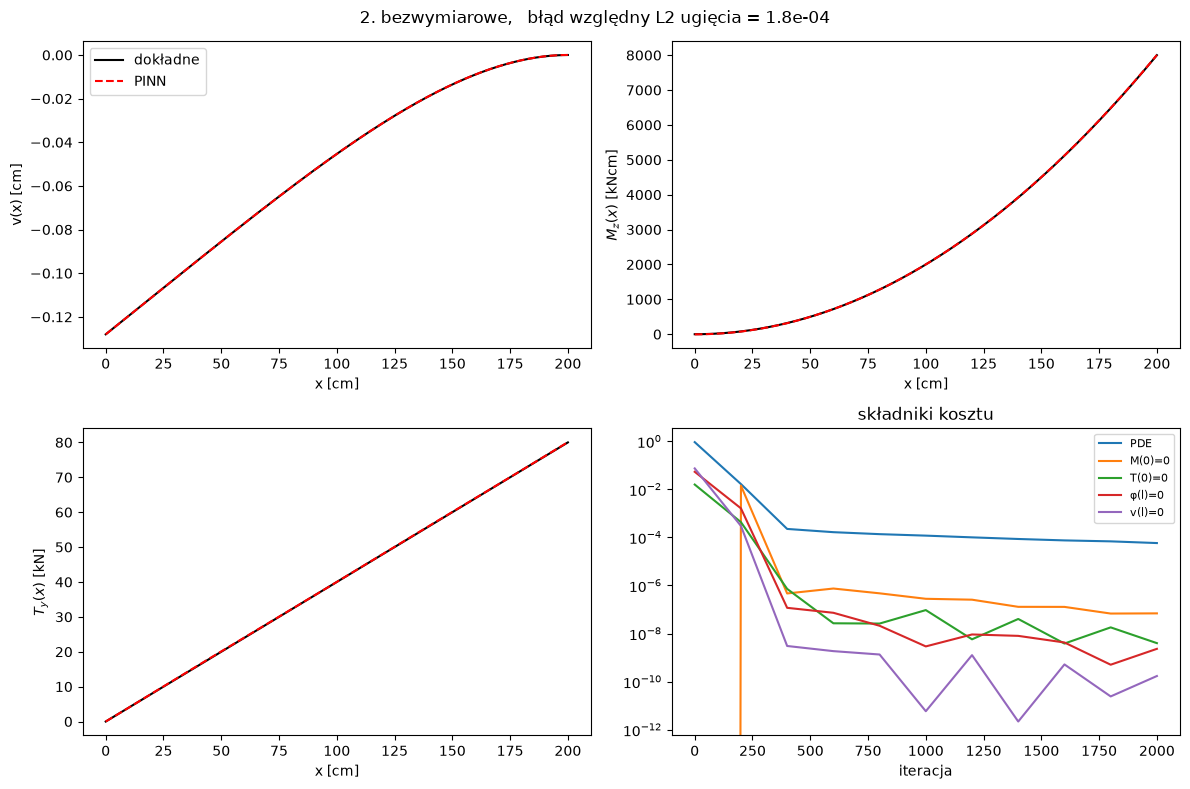

In [7]:
geom_xi = dde.geometry.Interval(0, 1)

# pochodne ugięcia po ξ
def dv_dxi(v, xi):
    return dde.grad.jacobian(v, xi)

def d2v_dxi2(v, xi):
    return dde.grad.jacobian(dv_dxi(v, xi), xi)

def d3v_dxi3(v, xi):
    return dde.grad.jacobian(d2v_dxi2(v, xi), xi)

def d4v_dxi4(v, xi):
    return dde.grad.jacobian(d3v_dxi3(v, xi), xi)

# równanie: d⁴v/dξ⁴ + γ_ref = 0
def pde_xi(xi, v):
    return d4v_dxi4(v, xi) + gamma

# warunki brzegowe
def bc_M_xi(xi, v, _):     # M_z(0) = 0
    return d2v_dxi2(v, xi)

def bc_T_xi(xi, v, _):     # T_y(0) = 0
    return d3v_dxi3(v, xi)

def bc_phi_xi(xi, v, _):   # φ(1) = 0
    return dv_dxi(v, xi)

bcs_xi = [
    dde.icbc.OperatorBC(geom_xi, bc_M_xi, free_end),
    dde.icbc.OperatorBC(geom_xi, bc_T_xi, free_end),
    dde.icbc.OperatorBC(geom_xi, bc_phi_xi, clamped_end),
    dde.icbc.DirichletBC(geom_xi, bc_v, clamped_end),   # v(1) = 0
]

model, losshistory2 = train(geom_xi, pde_xi, bcs_xi)

v2 = model.predict(xi)
M2 = model.predict(xi, operator=lambda xi, v: -E * J / l**2 * d2v_dxi2(v, xi))   # M_z = -EJ/l² d²v/dξ²
T2 = model.predict(xi, operator=lambda xi, v: -E * J / l**3 * d3v_dxi3(v, xi))   # T_y = -EJ/l³ d³v/dξ³
plot(v2, M2, T2, losshistory2, "2. bezwymiarowe")

In [8]:
print("\gamma_ref =", gamma, "cm")

\gamma_ref = 1.024 cm


<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_27529/4283839527.py:1: SyntaxWarning: invalid escape sequence '\g'
  print("\gamma_ref =", gamma, "cm")


## 3. Sformułowanie bezwymiarowe ze skalowaniem ugięcia $\hat v=\mathsf v/\gamma_{\mathrm{ref}}$, wagi jednostkowe

Podstawiamy $x=l\,\xi$ oraz $\mathsf v=\gamma_{\mathrm{ref}}\,\hat v$:

$$\frac{EJ_z\,\gamma_{\mathrm{ref}}}{l^4}\,\dfrac{d^4\hat v}{d\xi^4}+p=0\qquad\Rightarrow\qquad \gamma_{\mathrm{ref}}=\frac{p\,l^4}{EJ_z}$$

$$\dfrac{d^4\hat v}{d\xi^4}+1=0,\qquad \hat v(\xi)=\frac{4\xi-\xi^4-3}{24},\qquad \mathsf v=\gamma_{\mathrm{ref}}\,\hat v$$

$$\begin{aligned}
M_z(\xi)&=-\frac{EJ_z}{l^2}\,\dfrac{d^2\mathsf v}{d\xi^2}=-\frac{EJ_z\,\gamma_{\mathrm{ref}}}{l^2}\,\dfrac{d^2\hat v}{d\xi^2}=-\frac{EJ_z}{l^2}\cdot\frac{p\,l^4}{EJ_z}\,\dfrac{d^2\hat v}{d\xi^2}=-p\,l^2\,\dfrac{d^2\hat v}{d\xi^2}\\
T_y(\xi)&=-\frac{EJ_z}{l^3}\,\dfrac{d^3\mathsf v}{d\xi^3}=-\frac{EJ_z\,\gamma_{\mathrm{ref}}}{l^3}\,\dfrac{d^3\hat v}{d\xi^3}=-\frac{EJ_z}{l^3}\cdot\frac{p\,l^4}{EJ_z}\,\dfrac{d^3\hat v}{d\xi^3}=-p\,l\,\dfrac{d^3\hat v}{d\xi^3}
\end{aligned}$$

In [ ]:
# równanie: d⁴v̂/dξ⁴ + 1 = 0; warunki brzegowe jak w sformułowaniu 2
def pde_hat(xi, v_hat):
    return d4v_dxi4(v_hat, xi) + 1

model, losshistory3 = train(geom_xi, pde_hat, bcs_xi)

v3 = gamma * model.predict(xi)
M3 = model.predict(xi, operator=lambda xi, v_hat: -p * l**2 * d2v_dxi2(v_hat, xi))   # M_z = -p l² d²v̂/dξ²
T3 = model.predict(xi, operator=lambda xi, v_hat: -p * l * d3v_dxi3(v_hat, xi))      # T_y = -p l d³v̂/dξ³
plot(v3, M3, T3, losshistory3, "3. bezwymiarowe + γ")

Compiling model...
'compile' took 0.000145 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [8.73e-01, 0.00e+00, 1.58e-02, 5.36e-02, 7.41e-02]    [8.73e-01, 0.00e+00, 1.58e-02, 5.36e-02, 7.41e-02]    []  
200       [1.23e-02, 1.37e-02, 6.00e-04, 6.85e-04, 4.48e-04]    [1.23e-02, 1.37e-02, 6.00e-04, 6.85e-04, 4.48e-04]    []  
400       [2.07e-04, 3.35e-07, 3.80e-07, 4.55e-08, 9.86e-09]    [2.07e-04, 3.35e-07, 3.80e-07, 4.55e-08, 9.86e-09]    []  
600       [1.97e-04, 8.95e-07, 9.65e-07, 1.35e-06, 1.60e-07]    [1.97e-04, 8.95e-07, 9.65e-07, 1.35e-06, 1.60e-07]    []  
800       [5.39e-04, 1.64e-05, 8.95e-06, 1.68e-05, 3.43e-09]    [5.39e-04, 1.64e-05, 8.95e-06, 1.68e-05, 3.43e-09]    []  
1000      [1.15e-04, 3.26e-07, 5.60e-09, 1.03e-08, 1.83e-09]    [1.15e-04, 3.26e-07, 5.60e-09, 1.03e-08, 1.83e-09]    []  


## 4. Zestawienie

wariant   koszt końcowy   błąd L2
1a        1.4072275e-10 0.9997474268358063
1b        0.053462762 0.9990710972266085
2         78317.77 1.0933882388678424
3         3.897569e-05 0.0004335713780162302


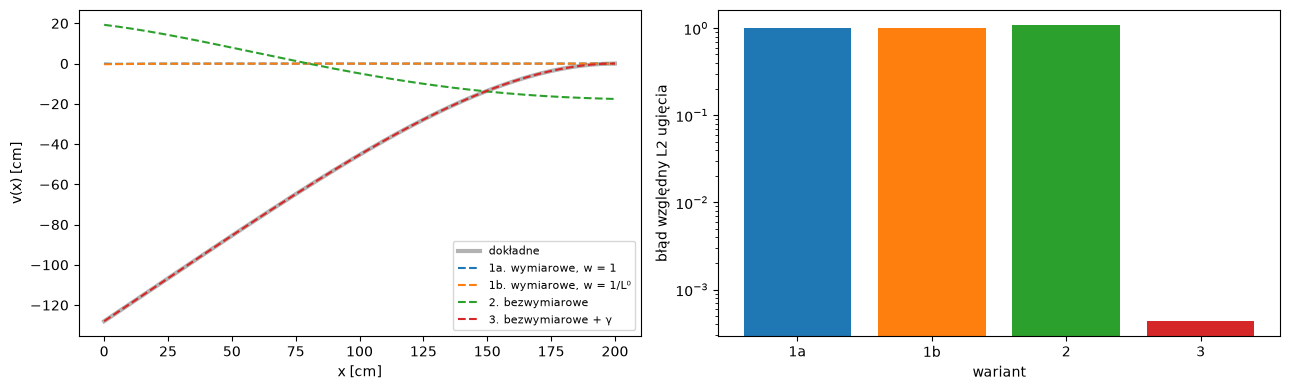

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(x, v_exact(x), "k-", lw=3, alpha=0.3, label="dokładne")
ax[0].plot(x, v1a, "--", label="1a. wymiarowe, w = 1")
ax[0].plot(x, v1b, "--", label="1b. wymiarowe, w = 1/L⁰")
ax[0].plot(x, v2, "--", label="2. bezwymiarowe")
ax[0].plot(x, v3, "--", label="3. bezwymiarowe + γ")
ax[0].set(xlabel="x [cm]", ylabel="v(x) [cm]")
ax[0].legend(fontsize=8)

names = ["1a", "1b", "2", "3"]
errors = [error_L2(v1a), error_L2(v1b), error_L2(v2), error_L2(v3)]
ax[1].bar(names, errors, color=["C0", "C1", "C2", "C3"])
ax[1].set_yscale("log")
ax[1].set(xlabel="wariant", ylabel="błąd względny L2 ugięcia")
fig.tight_layout()

print("wariant   koszt końcowy   błąd L2")
print("1a       ", sum(losshistory1a.loss_train[-1]), errors[0])
print("1b       ", sum(losshistory1b.loss_train[-1]), errors[1])
print("2        ", sum(losshistory2.loss_train[-1]), errors[2])
print("3        ", sum(losshistory3.loss_train[-1]), errors[3])